# qk Experiments Comparison (v1 + v2)
Compares v1 keep_* models (4 files) and v2 variants.


In [28]:
from pathlib import Path
import pandas as pd
import json

V1_DIR = Path('qk_experiments')
V2_DIR = Path('qk_experiments_v2')

V1_MODELS = sorted(V1_DIR.glob('model_keep_0_3_26'))
V2_MODELS = sorted(V2_DIR.glob('model_*'))

V1_MODELS, V2_MODELS


([WindowsPath('qk_experiments/model_keep_0_3_26')],
 [WindowsPath('qk_experiments_v2/model_calib_stratified'),
  WindowsPath('qk_experiments_v2/model_combined'),
  WindowsPath('qk_experiments_v2/model_ignore_expanded')])

In [29]:
def size_gb(path: Path):
    if not path or not path.exists():
        return None
    return round(path.stat().st_size / (1024**3), 3)

def gather(models, label):
    rows = []
    for mdir in models:
        name = mdir.name
        rows.append({
            'group': label,
            'name': name.replace('model_', ''),
            'model_dir': str(mdir),
            'zip_gb': None,
        })
    return rows

rows = gather(V1_MODELS, 'v1') + gather(V2_MODELS, 'v2')
df = pd.DataFrame(rows).sort_values(['group','name'])
df


,group,name,model_dir,zip_gb
0,v1,keep_0_3_26,qk_experiments\model_keep_0_3_26,None
1,v2,calib_stratified,qk_experiments_v2\model_calib_stratified,None
2,v2,combined,qk_experiments_v2\model_combined,None
3,v2,ignore_expanded,qk_experiments_v2\model_ignore_expanded,None


In [30]:
# Manual entry for official LB score/time (optional)
lb = {
    'keep_0_3_26': {'score': 0.587324618, 'time_min': None},
    # 'keep_0_3_26': {'score': 0.0, 'time_min': 0.0},
}

def lookup(name, key):
    return lb.get(name, {}).get(key)

df['lb_score'] = df['name'].apply(lambda n: lookup(n, 'score'))
df['time_min'] = df['name'].apply(lambda n: lookup(n, 'time_min'))
df


,group,name,model_dir,zip_gb,lb_score,time_min
0,v1,keep_0_3_26,qk_experiments\model_keep_0_3_26,None,0.587325,None
1,v2,calib_stratified,qk_experiments_v2\model_calib_stratified,None,NaN,None
2,v2,combined,qk_experiments_v2\model_combined,None,NaN,None
3,v2,ignore_expanded,qk_experiments_v2\model_ignore_expanded,None,NaN,None


In [31]:
# Local benchmark + auto scoring (optional)
import time
import re
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
MAX_NEW_TOKENS = 128

PROMPTS = [
    {
        'id': 'seq',
        'type': 'numeric',
        'prompt': '다음 수열의 다음 항을 추론해줘: 2, 6, 12, 20, 30, ?',
        'answer': 42,
    },
    {
        'id': 'code',
        'type': 'numeric',
        'prompt': '다음 파이썬 코드의 출력과 이유를 설명해줘:\nprint([i*i for i in range(5)][-2])',
        'answer': 9,
    },
    {
        'id': 'math',
        'type': 'numeric',
        'prompt': '정수 x, y가 x+y=17, x-y=5일 때 x*y는?',
        'answer': 72,
    },

]

In [32]:

def load_tokenizer(model_dir):
    try:
        return AutoTokenizer.from_pretrained(model_dir, trust_remote_code=True, fix_mistral_regex=True)
    except TypeError:
        return AutoTokenizer.from_pretrained(model_dir, trust_remote_code=True)

def finish_reason(gen_tokens, max_new_tokens):
    return 'length' if gen_tokens >= max_new_tokens else 'stop'

def extract_first_int(text):
    m = re.search(r'-?\d+', text)
    return int(m.group(0)) if m else None

def score_output(item, text):
    if item['type'] == 'numeric':
        val = extract_first_int(text)
        return 1 if val == item['answer'] else 0
    if item['type'] == 'format':
        words = re.findall(r'[A-Za-z0-9?-?]+', text)
        word_count = len(words)
        comma_ok = text.count(',') == 1
        nums = re.findall(r'\d+', text)
        num_ok = len(nums) == 2
        len_ok = 15 <= word_count <= 20
        return 1 if (comma_ok and num_ok and len_ok) else 0
    return None

In [33]:
def bench_model(model_dir):
    tokenizer = load_tokenizer(model_dir)
    model = AutoModelForCausalLM.from_pretrained(
        model_dir,
        dtype=torch.bfloat16 if DEVICE=='cuda' else None,
    )
    model.to(DEVICE)

    times = []
    gen_tokens_list = []
    finish_counts = {'length': 0, 'stop': 0}
    scores = []

    for item in PROMPTS:
        inputs = tokenizer(item['prompt'], return_tensors='pt').to(DEVICE)
        if DEVICE == 'cuda':
            torch.cuda.synchronize()
        t0 = time.time()
        out = model.generate(
            **inputs,
            max_new_tokens=MAX_NEW_TOKENS,
            return_dict_in_generate=True,
            output_scores=False,
        )
        if DEVICE == 'cuda':
            torch.cuda.synchronize()
        t1 = time.time()

        sequences = out.sequences
        gen_tokens = sequences.shape[-1] - inputs['input_ids'].shape[-1]
        gen_tokens_list.append(gen_tokens)
        times.append(t1 - t0)

        reason = finish_reason(gen_tokens, MAX_NEW_TOKENS)
        finish_counts[reason] += 1

        text = tokenizer.decode(sequences[0], skip_special_tokens=True)
        s = score_output(item, text)
        scores.append(s)

    total_time = sum(times)
    total_tokens = sum(gen_tokens_list)
    n = max(len(gen_tokens_list), 1)

    s = pd.Series(gen_tokens_list)
    score_vals = [x for x in scores if x is not None]
    score_total = sum(score_vals) if score_vals else 0
    score_count = len(score_vals)
    score_ratio = round(score_total / score_count, 3) if score_count else None

    return {
        'test_time_sec': round(total_time, 3),
        'out_tok_mean': round(total_tokens / n, 3),
        'out_tok_p50': float(s.quantile(0.50)),
        'out_tok_p90': float(s.quantile(0.90)),
        'out_tok_p95': float(s.quantile(0.95)),
        'tok_per_sec': round(total_tokens / max(total_time, 1e-6), 3),
        'max_length_finish_ratio': round(finish_counts['length'] / n, 3),
        'finish_reason_counts': finish_counts,
        'auto_score_ratio': score_ratio,
        'auto_score_total': score_total,
        'auto_score_count': score_count,
    }



bench_rows = []

for mdir in V1_MODELS + V2_MODELS:
    res = bench_model(mdir)
    try:
        import torch
        if torch.cuda.is_available():
            torch.cuda.empty_cache()
    except Exception:
        pass
    bench_rows.append({
        'name': mdir.name.replace('model_', ''),
        'group': 'v1' if mdir in V1_MODELS else 'v2',
        **res,
    })




The tokenizer you are loading from 'qk_experiments\model_keep_0_3_26' with an incorrect regex pattern: https://huggingface.co/mistralai/Mistral-Small-3.1-24B-Instruct-2503/discussions/84#69121093e8b480e709447d5e. This will lead to incorrect tokenization. You should set the `fix_mistral_regex=True` flag when loading this tokenizer to fix this issue.
Compressing model: 210it [00:02, 99.28it/s] 
The tokenizer you are loading from 'qk_experiments_v2\model_calib_stratified' with an incorrect regex pattern: https://huggingface.co/mistralai/Mistral-Small-3.1-24B-Instruct-2503/discussions/84#69121093e8b480e709447d5e. This will lead to incorrect tokenization. You should set the `fix_mistral_regex=True` flag when loading this tokenizer to fix this issue.
Compressing model: 210it [00:00, 1418.33it/s]
The tokenizer you are loading from 'qk_experiments_v2\model_combined' with an incorrect regex pattern: https://huggingface.co/mistralai/Mistral-Small-3.1-24B-Instruct-2503/discussions/84#69121093e8b4

In [34]:
bench_df = pd.DataFrame(bench_rows).sort_values(['group','name'])
bench_df


,name,group,test_time_sec,out_tok_mean,out_tok_p50,out_tok_p90,out_tok_p95,tok_per_sec,max_length_finish_ratio,finish_reason_counts,auto_score_ratio,auto_score_total,auto_score_count
0,keep_0_3_26,v1,17.160,43.333,1.0,102.6,115.3,7.576,0.333,"{'length': 1, 'stop': 2}",0.0,0,3
1,calib_stratified,v2,33.923,85.667,128.0,128.0,128.0,7.576,0.667,"{'length': 2, 'stop': 1}",0.0,0,3
2,combined,v2,253.486,43.333,1.0,102.6,115.3,0.513,0.333,"{'length': 1, 'stop': 2}",0.0,0,3
3,ignore_expanded,v2,17.900,43.333,1.0,102.6,115.3,7.263,0.333,"{'length': 1, 'stop': 2}",0.0,0,3


In [35]:
# Summary table
cols = ['group','name','auto_score_ratio','auto_score_total','auto_score_count','test_time_sec','tok_per_sec','out_tok_mean','out_tok_p50','out_tok_p90','out_tok_p95','max_length_finish_ratio']
bench_df[cols]


,group,name,auto_score_ratio,auto_score_total,auto_score_count,test_time_sec,tok_per_sec,out_tok_mean,out_tok_p50,out_tok_p90,out_tok_p95,max_length_finish_ratio
0,v1,keep_0_3_26,0.0,0,3,17.160,7.576,43.333,1.0,102.6,115.3,0.333
1,v2,calib_stratified,0.0,0,3,33.923,7.576,85.667,128.0,128.0,128.0,0.667
2,v2,combined,0.0,0,3,253.486,0.513,43.333,1.0,102.6,115.3,0.333
3,v2,ignore_expanded,0.0,0,3,17.900,7.263,43.333,1.0,102.6,115.3,0.333


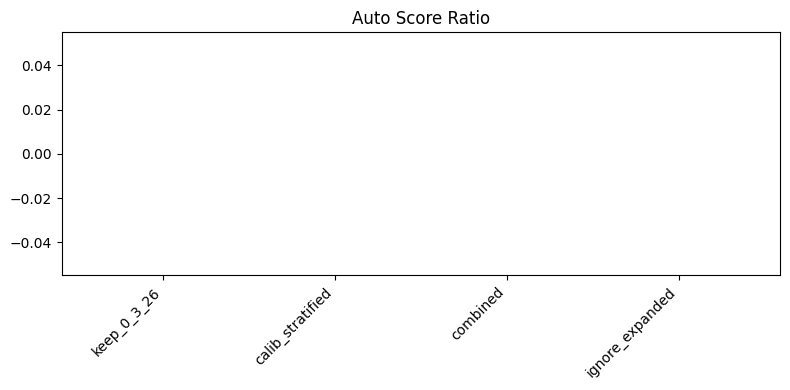

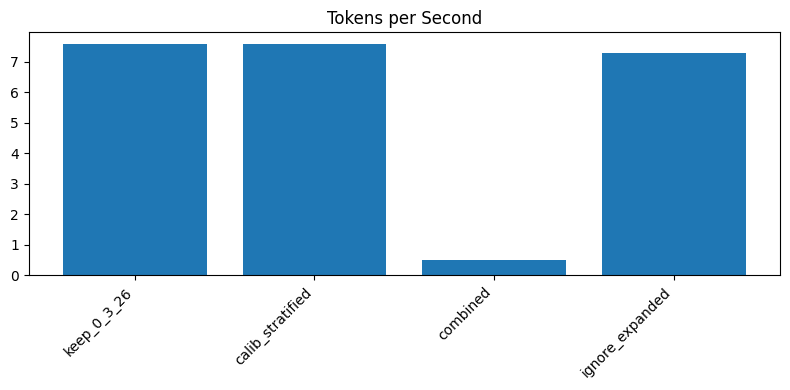

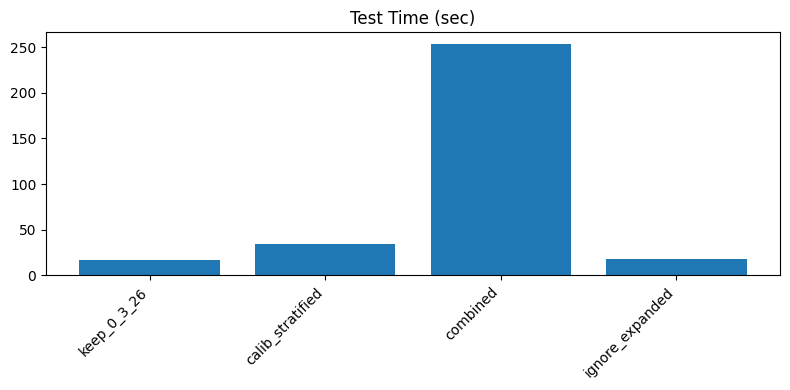

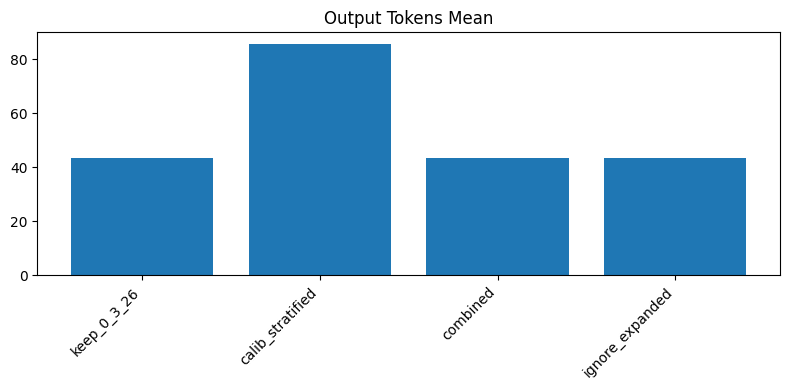

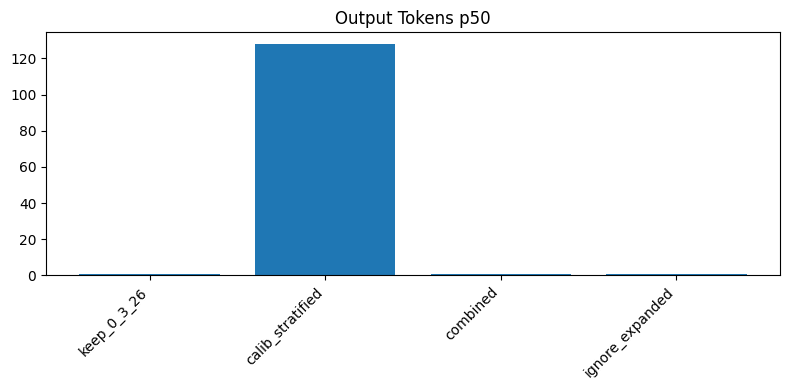

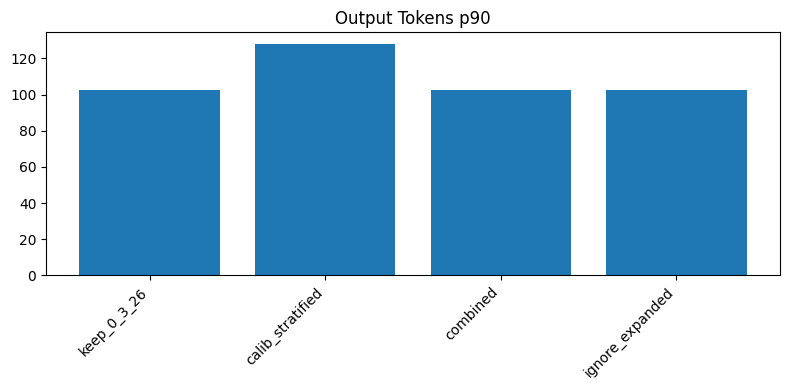

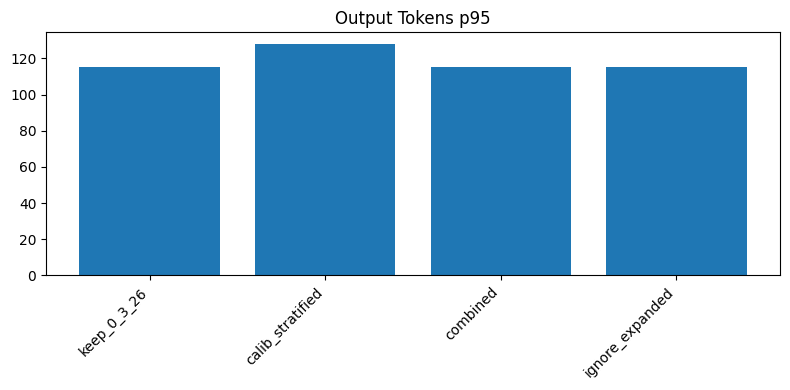

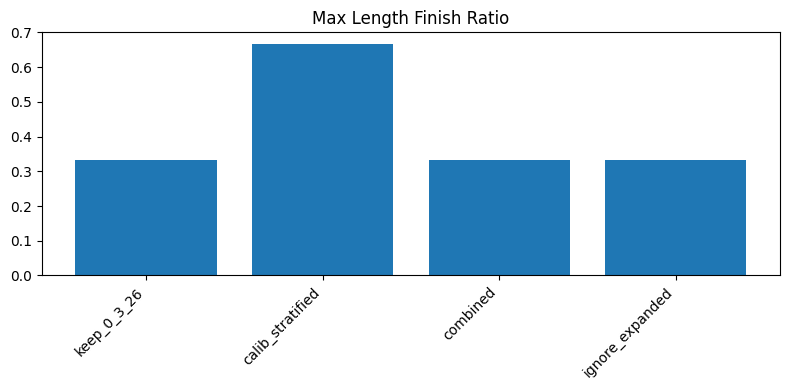

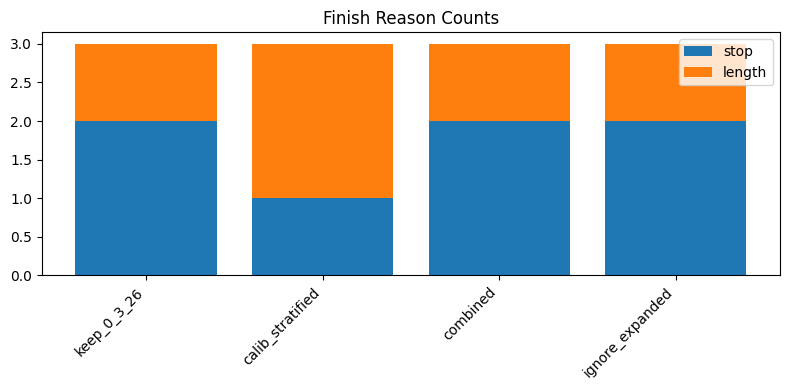

In [36]:

# Visualizations
import matplotlib.pyplot as plt
metrics = [
    ('auto_score_ratio', 'Auto Score Ratio'),
    ('tok_per_sec', 'Tokens per Second'),
    ('test_time_sec', 'Test Time (sec)'),
    ('out_tok_mean', 'Output Tokens Mean'),
    ('out_tok_p50', 'Output Tokens p50'),
    ('out_tok_p90', 'Output Tokens p90'),
    ('out_tok_p95', 'Output Tokens p95'),
    ('max_length_finish_ratio', 'Max Length Finish Ratio'),
    ('finish_reason_counts', 'Finish Reason Counts'),
]
for key, title in metrics:
    if key == 'finish_reason_counts':
        fr = bench_df['finish_reason_counts'].apply(lambda x: x or {})
        lengths = fr.apply(lambda d: d.get('length', 0))
        stops = fr.apply(lambda d: d.get('stop', 0))
        plt.figure(figsize=(8, 4))
        plt.bar(bench_df['name'], stops, label='stop')
        plt.bar(bench_df['name'], lengths, bottom=stops, label='length')
        plt.title(title)
        plt.xticks(rotation=45, ha='right')
        plt.legend()
        plt.tight_layout()
        plt.show()
        continue
    if key not in bench_df.columns:
        continue
    plt.figure(figsize=(8, 4))
    plt.bar(bench_df['name'], bench_df[key])
    plt.title(title)
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()
